Cargamos el dataset de los pingüinos en un DataFrame de Pandas.

In [1]:
import pandas as pd
penguins = pd.read_csv('https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/penguins.csv').dropna()
penguins.shape

(333, 9)

In [2]:
penguins

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,6,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
...,...,...,...,...,...,...,...,...,...
339,340,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,341,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,342,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,343,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [3]:
# Separate predictor variables from the class labels
X = penguins.drop(['species','rowid'], axis=1)
X = X.drop(['island', 'sex'], axis=1)
y = penguins.species.astype("category").cat.codes # Mapping class labels into numerical code
y.unique()
X

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,39.1,18.7,181.0,3750.0,2007
1,39.5,17.4,186.0,3800.0,2007
2,40.3,18.0,195.0,3250.0,2007
4,36.7,19.3,193.0,3450.0,2007
5,39.3,20.6,190.0,3650.0,2007
...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,2009
340,43.5,18.1,202.0,3400.0,2009
341,49.6,18.2,193.0,3775.0,2009
342,50.8,19.0,210.0,4100.0,2009


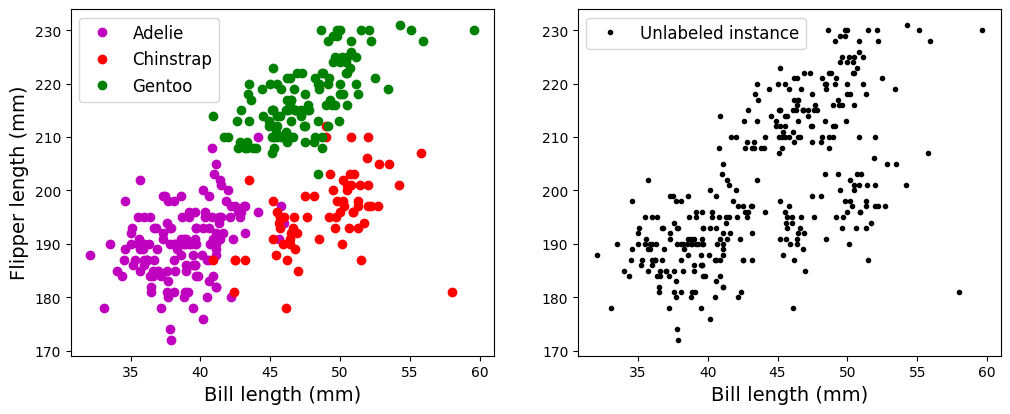

In [4]:
import matplotlib.pyplot as plt
plt.figure (figsize=(12, 4.5))

# Let's do a 'double' visualization of the data: with its labels and without the labels.
# For clustering we must assume the "no label" scenario.
plt.subplot(121)
plt.plot(X[y==0]["bill_length_mm"], X[y==0]["flipper_length_mm"], "mo", label="Adelie")
plt.plot(X[y==1]["bill_length_mm"], X[y==1]["flipper_length_mm"], "ro", label="Chinstrap")
plt.plot(X[y==2]["bill_length_mm"], X[y==2]["flipper_length_mm"], "go", label="Gentoo")
plt.xlabel("Bill length (mm)", fontsize=14)
plt.ylabel("Flipper length (mm)", fontsize=14)
plt.legend(fontsize=12)

plt.subplot(122)
plt.plot(X["bill_length_mm"], X["flipper_length_mm"], "k.", label="Unlabeled instance")
plt.xlabel("Bill length (mm)", fontsize=14)
plt.legend(fontsize=12)

plt.show()

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, n_init=100)
X["cluster"] = kmeans.fit_predict(X)
X

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,cluster
0,39.1,18.7,181.0,3750.0,2007,0
1,39.5,17.4,186.0,3800.0,2007,0
2,40.3,18.0,195.0,3250.0,2007,0
4,36.7,19.3,193.0,3450.0,2007,0
5,39.3,20.6,190.0,3650.0,2007,0
...,...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,2009,2
340,43.5,18.1,202.0,3400.0,2009,0
341,49.6,18.2,193.0,3775.0,2009,0
342,50.8,19.0,210.0,4100.0,2009,2


In [6]:
kmeans.inertia_

28336653.83683084

In [7]:
kmeans.cluster_centers_

array([[  41.2863354 ,   18.03726708,  190.08695652, 3522.04968944,
        2008.00621118],
       [  48.93571429,   15.53142857,  220.61428571, 5435.35714286,
        2008.05714286],
       [  44.87254902,   16.90882353,  204.65686275, 4445.34313725,
        2008.08823529]])

<function matplotlib.pyplot.show(close=None, block=None)>

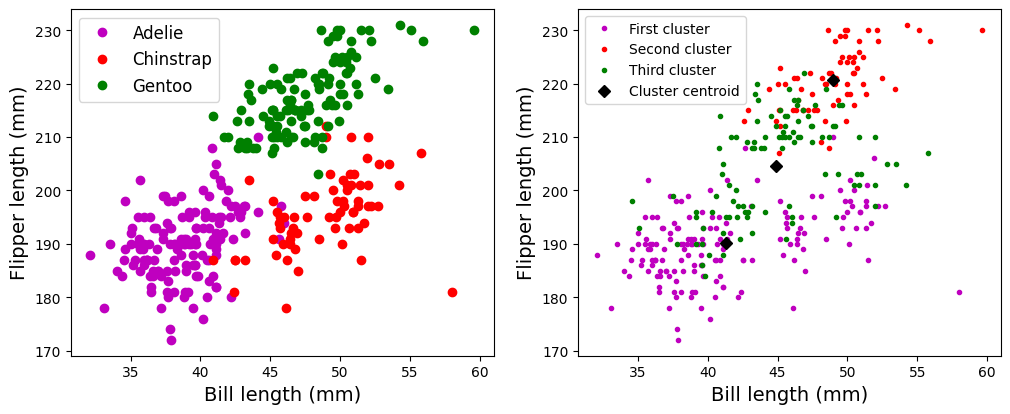

In [8]:
plt.figure (figsize=(12, 4.5))

# Let's do a 'double' visualization of the data: data with the original labels,
# and the clustering results.
plt.subplot(121)
plt.plot(X[y==0]["bill_length_mm"], X[y==0]["flipper_length_mm"], "mo", label="Adelie")
plt.plot(X[y==1]["bill_length_mm"], X[y==1]["flipper_length_mm"], "ro", label="Chinstrap")
plt.plot(X[y==2]["bill_length_mm"], X[y==2]["flipper_length_mm"], "go", label="Gentoo")
plt.xlabel("Bill length (mm)", fontsize=14)
plt.ylabel("Flipper length (mm)", fontsize=14)
plt.legend(fontsize=12)

plt.subplot(122)
plt.plot(X[X["cluster"]==0]["bill_length_mm"],
         X[X["cluster"]==0]["flipper_length_mm"], "m.", label="First cluster")
plt.plot(X[X["cluster"]==1]["bill_length_mm"],
         X[X["cluster"]==1]["flipper_length_mm"], "r.", label="Second cluster")
plt.plot(X[X["cluster"]==2]["bill_length_mm"],
         X[X["cluster"]==2]["flipper_length_mm"], "g.", label="Third cluster")
plt.plot(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,2],
         "kD", label="Cluster centroid")
plt.xlabel("Bill length (mm)", fontsize=14)
plt.ylabel("Flipper length (mm)", fontsize=14)
plt.legend(fontsize=10)

plt.show

In [9]:
# What if we try applying K-means over a narrower selection of penguins' attributes? would it improve the clustering?
X_selected = X[["bill_length_mm", "flipper_length_mm"]]
kmeans_selected = KMeans(n_clusters=3, n_init=50)
X_selected["cluster"] = kmeans_selected.fit_predict(X_selected)
X_selected

/tmp/ipykernel_1469/879789049.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_selected["cluster"] = kmeans_selected.fit_predict(X_selected)


,bill_length_mm,flipper_length_mm,cluster
0,39.1,181.0,1
1,39.5,186.0,1
2,40.3,195.0,2
4,36.7,193.0,1
5,39.3,190.0,1
...,...,...,...
339,55.8,207.0,0
340,43.5,202.0,2
341,49.6,193.0,2
342,50.8,210.0,0


In [10]:
kmeans_selected.inertia_

13858.94307215541

<function matplotlib.pyplot.show(close=None, block=None)>

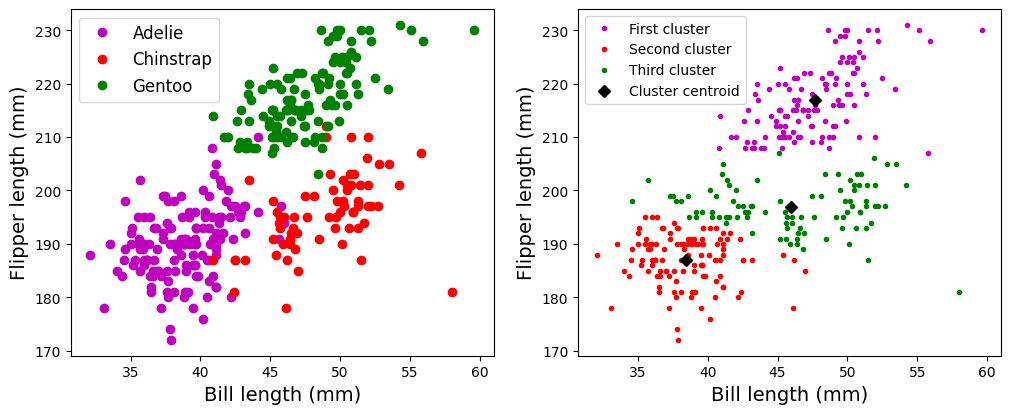

In [11]:
plt.figure (figsize=(12, 4.5))

# Let's do a 'double' visualization of the data: data with the original labels,
# and the clustering results.
plt.subplot(121)
plt.plot(X[y==0]["bill_length_mm"], X[y==0]["flipper_length_mm"], "mo", label="Adelie")
plt.plot(X[y==1]["bill_length_mm"], X[y==1]["flipper_length_mm"], "ro", label="Chinstrap")
plt.plot(X[y==2]["bill_length_mm"], X[y==2]["flipper_length_mm"], "go", label="Gentoo")
plt.xlabel("Bill length (mm)", fontsize=14)
plt.ylabel("Flipper length (mm)", fontsize=14)
plt.legend(fontsize=12)

plt.subplot(122)
plt.plot(X_selected[X_selected["cluster"]==0]["bill_length_mm"],
         X_selected[X_selected["cluster"]==0]["flipper_length_mm"], "m.", label="First cluster")
plt.plot(X_selected[X_selected["cluster"]==1]["bill_length_mm"],
         X_selected[X_selected["cluster"]==1]["flipper_length_mm"], "r.", label="Second cluster")
plt.plot(X_selected[X_selected["cluster"]==2]["bill_length_mm"],
         X_selected[X_selected["cluster"]==2]["flipper_length_mm"], "g.", label="Third cluster")
plt.plot(kmeans_selected.cluster_centers_[:,0], kmeans_selected.cluster_centers_[:,1],
         "kD", label="Cluster centroid")
plt.xlabel("Bill length (mm)", fontsize=14)
plt.ylabel("Flipper length (mm)", fontsize=14)
plt.legend(fontsize=10)

plt.show

** CÓDIGO DE AYUDA PARA EL MÉTODO DEL CODO **

In [12]:
from sklearn.cluster import KMeans

inertia_values = []

for k in range(1, 6):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_selected)
    inertia_values.append(kmeans.inertia_)

print("Valores de inertia k = 1 a 5:")
print(inertia_values)

Valores de inertia k = 1 a 5:
[75362.83663663661, 21032.22422105262, 13858.94307215541, 9606.84798409778, 7459.287165466718]


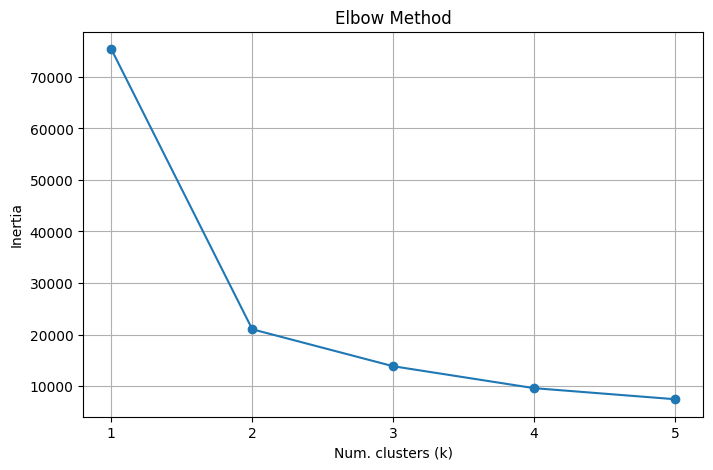

In [13]:
import matplotlib.pyplot as plt

k_values = range(1, 6)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o', linestyle='-')
plt.title('Elbow Method')
plt.xlabel('Num. clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()


**CLUSTERING CON DATOS DE VARIOS TIPOS**: K-Prototypes

Si quisiéramos incorporar en el proceso de clustering las dos variables categóricas de los pingüinos (isla y género), necesitaríamos otro algoritmo de clustering que, a diferencia de K-means, sea capaz de incorporar variables de distintos tipos, no exclusivamente numéricas, en el proceso de aprendizaje.
Un ejemplo de **K-prototypes**, que combina dos algoritmos básicos:  **K-means** (para variables numéricas) y **K-modes** (basado en la moda estadística, para variables categóricas) para manejar conjuntos de datos mixtos de manera eficiente.

In [14]:
!pip install kmodes

In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

# Cargamos el dataset tal como indicaste
penguins = pd.read_csv('https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/penguins.csv').dropna()

In [16]:
# Separamos las columnas por tipo
cat_cols = ['species', 'island', 'sex']
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Estandarizamos solo las numéricas (Media 0, Desviación típica 1)
scaler = StandardScaler()
penguins_scaled = penguins.copy()
penguins_scaled[num_cols] = scaler.fit_transform(penguins[num_cols])

In [17]:
# Obtener las posiciones (índices) de las columnas categóricas: la clase KPrototypes necesita esto
cat_indices = [penguins.columns.get_loc(col) for col in cat_cols]

# Convertimos DataFrame a matriz de Numpy
data_matrix = penguins_scaled.values

In [18]:
# k=3 porque sabemos que hay 3 especies (Adelie, Chinstrap, Gentoo)
kproto = KPrototypes(n_clusters=3, init='Cao', gamma=0.0, random_state=42, n_jobs=-1)

# Ajustamos el modelo y asignamos clústeres en un solo paso
clusters = kproto.fit_predict(data_matrix, categorical=cat_indices)

# Añadimos los resultados al DataFrame original (sin escalar) para poder interpretarlos
penguins['cluster_asignado'] = clusters

In [19]:
# Comparamos los clústeres descubiertos con las especies reales
print(pd.crosstab(penguins['species'], penguins['cluster_asignado']))

cluster_asignado   0   1    2
species                      
Adelie             0  34  112
Chinstrap         68   0    0
Gentoo            41  78    0


Existen un hiperparámetro 'gamma' que permite controlar el peso de las categorías frente a los atributos numéricos. Prueba a usarlo como argumento en KPrototypes:

```
gamma=0.5
```

